In [ ]:
# CodeAlpha Task 2: Exploratory Data Analysis
# Smartphone Dataset

In [1]:
import numpy as np
import pandas as pd


In [2]:
data = pd.read_excel("smartphones.xlsx")

print("Rows and Columns:", data.shape)

print("\nFirst 5 Rows:")
print(data.head())


Rows and Columns: (1020, 11)

First 5 Rows:
                       model    price  rating  \
0              OnePlus 11 5G  ₹54,999    89.0   
1  OnePlus Nord CE 2 Lite 5G  ₹19,989    81.0   
2      Samsung Galaxy A14 5G  ₹16,499    75.0   
3       Motorola Moto G62 5G  ₹14,999    81.0   
4         Realme 10 Pro Plus  ₹24,999    82.0   

                                       sim  \
0  Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC   
1       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   
2       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   
3       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   
4       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   

                                         processor                        ram  \
0  Snapdragon 8 Gen2, Octa Core, 3.2 GHz Processor  12 GB RAM, 256 GB inbuilt   
1     Snapdragon 695, Octa Core, 2.2 GHz Processor   6 GB RAM, 128 GB inbuilt   
2        Exynos 1330, Octa Core, 2.4 GHz Processor    4 GB RAM, 64 GB inbuilt   
3    Snapdragon  695, Octa Core, 2.2 GHz Processor   6 GB RA

In [3]:
#basic data structure
print(data.columns)

print("\nData Types:")
print(data.dtypes)

print("\nDataset Info:")
print(data.info())

print("\nBasic Statistical Summary:")
print(data.describe())



Index(['model', 'price', 'rating', 'sim', 'processor', 'ram', 'battery',
       'display', 'camera', 'card', 'os'],
      dtype='object')

Data Types:
model         object
price         object
rating       float64
sim           object
processor     object
ram           object
battery       object
display       object
camera        object
card          object
os            object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   model      1020 non-null   object 
 1   price      1020 non-null   object 
 2   rating     879 non-null    float64
 3   sim        1020 non-null   object 
 4   processor  1020 non-null   object 
 5   ram        1020 non-null   object 
 6   battery    1020 non-null   object 
 7   display    1020 non-null   object 
 8   camera     1019 non-null   object 
 9   card       1013 non-null   object 
 1

In [4]:
# What i am finding
print("1. Which smartphone brands have the most models?")
print("2. What is the price distribution of smartphones?")
print("3. Which price segment has the best average rating?")
print("4. Are 5G phones more expensive and better rated than non-5G phones?")
print("5. Which features are most related to rating?")
print("6. Which phones provide the best value for money?")

1. Which smartphone brands have the most models?
2. What is the price distribution of smartphones?
3. Which price segment has the best average rating?
4. Are 5G phones more expensive and better rated than non-5G phones?
5. Which features are most related to rating?
6. Which phones provide the best value for money?


In [5]:
print("\nDuplicate Rows:")
print(data.duplicated().sum())

missing_values = pd.DataFrame({
    "missing_values": data.isnull().sum(),
    "missing_percent": (data.isnull().sum() / len(data) * 100).round(2)
})

print("\nMissing Values:")
print(missing_values)



Duplicate Rows:
0

Missing Values:
           missing_values  missing_percent
model                   0             0.00
price                   0             0.00
rating                141            13.82
sim                     0             0.00
processor               0             0.00
ram                     0             0.00
battery                 0             0.00
display                 0             0.00
camera                  1             0.10
card                    7             0.69
os                     17             1.67


In [6]:
df = data.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns)



Cleaned Column Names:
Index(['model', 'price', 'rating', 'sim', 'processor', 'ram', 'battery',
       'display', 'camera', 'card', 'os'],
      dtype='object')


In [7]:
df["price"] = (
    df["price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["price"] = pd.to_numeric(df["price"], errors="coerce")
print(df["price"])

0       54999
1       19989
2       16499
3       14999
4       24999
        ...  
1015    34990
1016    14990
1017    28990
1018    19990
1019    24990
Name: price, Length: 1020, dtype: int64


In [8]:
df["brand"] = df["model"].astype(str).str.split().str[0]
df['brand']

,brand
0,OnePlus
1,OnePlus
2,Samsung
3,Motorola
4,Realme
...,...
1015,Motorola
1016,Honor
1017,POCO
1018,Motorola


In [9]:
df["is_5g"] = df["sim"].astype(str).str.contains("5G", case=False, na=False)

df["ram_gb"] = pd.to_numeric(
    df["ram"].astype(str).str.extract(r"(\d+)\s*GB\s*RAM")[0],
    errors="coerce"
)

gb_storage = pd.to_numeric(
    df["ram"].astype(str).str.extract(r"(\d+)\s*GB\s*inbuilt")[0],
    errors="coerce"
)

tb_storage = pd.to_numeric(
    df["ram"].astype(str).str.extract(r"(\d+)\s*TB\s*inbuilt")[0],
    errors="coerce"
) * 1024

df["storage_gb"] = gb_storage.fillna(tb_storage)

df["battery_mah"] = pd.to_numeric(
    df["battery"].astype(str).str.extract(r"(\d+)\s*mAh")[0],
    errors="coerce"
)

df["charging_watt"] = pd.to_numeric(
    df["battery"].astype(str).str.extract(r"(\d+)W")[0],
    errors="coerce"
)

df["display_inches"] = pd.to_numeric(
    df["display"].astype(str).str.extract(r"(\d+\.?\d*)\s*inches")[0],
    errors="coerce"
)

df["refresh_rate_hz"] = pd.to_numeric(
    df["display"].astype(str).str.extract(r"(\d+)\s*Hz")[0],
    errors="coerce"
)

df["rear_camera_mp"] = pd.to_numeric(
    df["camera"].astype(str).str.extract(r"(\d+\.?\d*)\s*MP")[0],
    errors="coerce"
)

df["front_camera_mp"] = pd.to_numeric(
    df["camera"].astype(str).str.extract(r"&\s*(\d+\.?\d*)\s*MP\s*Front")[0],
    errors="coerce"
)

df["card_supported"] = ~df["card"].astype(str).str.contains(
    "Not Supported",
    case=False,
    na=False
)

df["android_version"] = pd.to_numeric(
    df["os"].astype(str).str.extract(r"Android\s*v(\d+)")[0],
    errors="coerce"
)

In [10]:

df["price_segment"] = pd.cut(
    df["price"],
    bins=[0, 10000, 20000, 30000, 50000, 100000, np.inf],
    labels=[
        "Below 10k",
        "10k-20k",
        "20k-30k",
        "30k-50k",
        "50k-100k",
        "100k+"
    ]
)

print("\nData After Feature Extraction:")
print(df.head())



Data After Feature Extraction:
                       model  price  rating  \
0              OnePlus 11 5G  54999    89.0   
1  OnePlus Nord CE 2 Lite 5G  19989    81.0   
2      Samsung Galaxy A14 5G  16499    75.0   
3       Motorola Moto G62 5G  14999    81.0   
4         Realme 10 Pro Plus  24999    82.0   

                                       sim  \
0  Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi, NFC   
1       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   
2       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   
3       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   
4       Dual Sim, 3G, 4G, 5G, VoLTE, Wi-Fi   

                                         processor                        ram  \
0  Snapdragon 8 Gen2, Octa Core, 3.2 GHz Processor  12 GB RAM, 256 GB inbuilt   
1     Snapdragon 695, Octa Core, 2.2 GHz Processor   6 GB RAM, 128 GB inbuilt   
2        Exynos 1330, Octa Core, 2.4 GHz Processor    4 GB RAM, 64 GB inbuilt   
3    Snapdragon  695, Octa Core, 2.2 GHz Processor   6 GB RAM, 128 GB inbuilt   
4  

In [11]:
#top brands
brand_counts = df["brand"].value_counts().head(10)

print("\nTop 10 Brands by Number of Models:")
print(brand_counts)




Top 10 Brands by Number of Models:
brand
Samsung     135
Xiaomi      135
Vivo        111
Realme       97
OPPO         62
Motorola     53
Apple        47
OnePlus      42
Tecno        33
iQOO         32
Name: count, dtype: int64


In [12]:
print("\nPrice Distribution:")
print(df["price"].describe().round(2))

print("\nCheapest Phones:")
print(df[["model", "brand", "price", "rating"]].sort_values("price").head(10))

print("\nMost Expensive Phones:")
print(df[["model", "brand", "price", "rating"]].sort_values("price", ascending=False).head(10))



Price Distribution:
count      1020.00
mean      31371.77
std       39168.94
min          99.00
25%       12464.25
50%       19815.00
75%       34999.00
max      650000.00
Name: price, dtype: float64

Cheapest Phones:
                 model     brand  price  rating
608  Namotel Achhe Din   Namotel     99     NaN
835     Eunity U1 King    Eunity    599     NaN
932     Eunity U1 Livo    Eunity    649     NaN
611    Eunity U1 5605N    Eunity    699     NaN
665       itel it2163S      itel    958     NaN
757       Karbonn KU3i   Karbonn    995     NaN
640     Nokia 105 Plus     Nokia   1299     NaN
573   Nokia 105 (2019)     Nokia   1299     NaN
647  Motorola Moto A10  Motorola   1339     NaN
881   Nokia 110 (2022)     Nokia   1599     NaN

Most Expensive Phones:
                                      model   brand   price  rating
431                   Vertu Signature Touch   Vertu  650000    62.0
921  Xiaomi Redmi K20 Pro Signature Edition  Xiaomi  480000    88.0
483        Huawei Mate 50

In [13]:
segment_summary = df.groupby("price_segment", observed=False).agg(
    models=("model", "count"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    average_rating=("rating", "mean"),
    median_rating=("rating", "median")
).round(2)

print("\nPrice Segment Summary:")
print(segment_summary)


Price Segment Summary:
               models  average_price  median_price  average_rating  \
price_segment                                                        
Below 10k         179        6805.73        7499.0           65.63   
10k-20k           368       15256.94       14999.0           76.41   
20k-30k           179       25488.87       24999.0           81.99   
30k-50k           133       39287.37       39990.0           84.26   
50k-100k          113       70203.72       69990.0           84.70   
100k+              48      155118.23      129990.0           81.23   

               median_rating  
price_segment                 
Below 10k               65.0  
10k-20k                 77.0  
20k-30k                 83.0  
30k-50k                 85.0  
50k-100k                87.0  
100k+                   82.0  


In [14]:
network_summary = df.groupby("is_5g").agg(
    models=("model", "count"),
    average_price=("price", "mean"),
    median_price=("price", "median"),
    average_rating=("rating", "mean"),
    average_ram=("ram_gb", "mean"),
    average_storage=("storage_gb", "mean")
).round(2)

network_summary.index = ["Non-5G", "5G"]

print("\n5G vs Non-5G Summary:")
print(network_summary)



5G vs Non-5G Summary:
        models  average_price  median_price  average_rating  average_ram  \
Non-5G     471       17584.15       11999.0           73.31         4.88   
5G         549       43200.49       29999.0           82.19         7.87   

        average_storage  
Non-5G            91.43  
5G               179.35  


In [15]:
numeric_columns = [
    "price",
    "rating",
    "ram_gb",
    "storage_gb",
    "battery_mah",
    "charging_watt",
    "display_inches",
    "refresh_rate_hz",
    "rear_camera_mp",
    "front_camera_mp"
]

correlation_with_rating = (
    df[numeric_columns]
    .corr(numeric_only=True)["rating"]
    .sort_values(ascending=False)
    .round(3)
)

print("\nCorrelation With Rating:")
print(correlation_with_rating)




Correlation With Rating:
rating             1.000
ram_gb             0.759
front_camera_mp    0.582
rear_camera_mp     0.572
charging_watt      0.528
refresh_rate_hz    0.509
storage_gb         0.481
display_inches     0.300
price              0.284
battery_mah       -0.016
Name: rating, dtype: float64


In [16]:
df["value_score"] = (df["rating"] / df["price"]) * 100000

best_value = (
    df.dropna(subset=["value_score", "rating", "price"])
    .sort_values("value_score", ascending=False)
)

print("\nTop 10 Best Value for Money Phones:")
print(
    best_value[
        [
            "model",
            "brand",
            "price",
            "rating",
            "ram_gb",
            "storage_gb",
            "is_5g",
            "value_score"
        ]
    ].head(10).round(2)
)


Top 10 Best Value for Money Phones:
                           model     brand  price  rating  ram_gb  storage_gb  \
190                   Realme C2s    Realme   3499    63.0     3.0        32.0   
478                  Lyf Earth 1       Lyf   3990    60.0     3.0        32.0   
786               Micromax IN 2C  Micromax   5999    60.0     3.0        32.0   
658             Letv Y1 Pro Plus      Letv   5999    60.0     6.0        64.0   
262                     POCO C31      POCO   6499    65.0     3.0        32.0   
778          Tecno Spark Go 2022     Tecno   6249    61.0     2.0        32.0   
302  Realme C30 (3GB RAM + 32GB)    Realme   6299    60.0     3.0        32.0   
650               Micromax IN 2B  Micromax   6999    66.0     4.0        64.0   
984                   Realme C11    Realme   6490    61.0     2.0        32.0   
972              Realme C11 2021    Realme   6499    61.0     2.0        32.0   

     is_5g  value_score  
190  False      1800.51  
478  False      150

In [17]:

#  ANOMALY DETECTION
low_limit = df["price"].quantile(0.01)
high_limit = df["price"].quantile(0.99)

anomalies = df[
    (df["price"] < low_limit) |
    (df["price"] > high_limit)
]

print("\nPrice Anomalies:")
print(
    anomalies[
        ["model", "brand", "price", "rating"]
    ].sort_values("price", ascending=False)
)



Price Anomalies:
                                        model     brand   price  rating
431                     Vertu Signature Touch     Vertu  650000    62.0
921    Xiaomi Redmi K20 Pro Signature Edition    Xiaomi  480000    88.0
483          Huawei Mate 50 RS Porsche Design    Huawei  239999    81.0
990          Huawei Mate 30 RS Porsche Design    Huawei  214990     NaN
462                       Xiaomi Mi Mix Alpha    Xiaomi  199990     NaN
290             Apple iPhone 14 Pro Max (1TB)     Apple  182999    78.0
781             Apple iPhone 13 Pro Max (1TB)     Apple  179900    86.0
814                 Apple iPhone 14 Pro (1TB)     Apple  172999    77.0
764           Apple iPhone 14 Pro Max (512GB)     Apple  169900    78.0
993                             Huawei Mate X    Huawei  169000     NaN
943  Samsung Galaxy Z Fold 4 (12GB RAM + 1TB)   Samsung  163980     NaN
927                        Samsung Guru E1200   Samsung    1685     NaN
881                          Nokia 110 (2022) 

In [18]:
# BRAND RATING ANALYSIS
brand_rating = df.groupby("brand").agg(
    models=("model", "count"),
    average_rating=("rating", "mean"),
    average_price=("price", "mean")
).round(2)

brand_rating = brand_rating[brand_rating["models"] >= 10]
brand_rating = brand_rating.sort_values("average_rating", ascending=False)

print("\nTop Brands by Average Rating:")
print(brand_rating.head(10))



Top Brands by Average Rating:
          models  average_rating  average_price
brand                                          
OnePlus       42           82.24       35858.57
iQOO          32           82.22       30301.88
Motorola      53           80.10       23670.47
Huawei        16           80.00       80177.25
Oppo          26           80.00       39874.46
POCO          13           78.85       20273.85
Xiaomi       135           78.78       27767.32
Samsung      135           78.72       36064.92
Poco          28           78.63       17645.96
OPPO          62           78.32       25362.37


In [19]:
#  PROCESSOR FAMILY ANALYSIS
conditions = [
    df["processor"].astype(str).str.contains("Snapdragon", case=False, na=False),
    df["processor"].astype(str).str.contains("Dimensity", case=False, na=False),
    df["processor"].astype(str).str.contains("Exynos", case=False, na=False),
    df["processor"].astype(str).str.contains("Bionic", case=False, na=False),
    df["processor"].astype(str).str.contains("Helio", case=False, na=False),
    df["processor"].astype(str).str.contains("Unisoc", case=False, na=False)
]

choices = [
    "Snapdragon",
    "Dimensity",
    "Exynos",
    "Bionic",
    "Helio",
    "Unisoc"
]

df["processor_family"] = np.select(
    conditions,
    choices,
    default="Other"
)

processor_summary = df.groupby("processor_family").agg(
    models=("model", "count"),
    average_price=("price", "mean"),
    average_rating=("rating", "mean")
).round(2)

processor_summary = processor_summary.sort_values("models", ascending=False)

print("\nProcessor Family Summary:")
print(processor_summary)



Processor Family Summary:
                  models  average_price  average_rating
processor_family                                       
Snapdragon           413       39687.90           81.55
Helio                202       12405.82           72.48
Dimensity            177       26163.67           81.13
Other                106       19546.48           69.94
Exynos                50       37841.52           80.37
Bionic                44       97487.98           77.19
Unisoc                28        7774.36           65.53


In [20]:
# 19. FINAL INSIGHTS

print("\nFinal Insights:")
print("1. Dataset has useful smartphone information for EDA.")
print("2. Missing values exist in some columns, especially rating.")
print("3. Samsung, Xiaomi, Vivo, Realme, and OPPO have many models.")
print("4. Price has a wide range, so median price is more reliable than mean price.")
print("5. 5G phones are generally more expensive and have better specifications.")
print("6. Rating is more related to storage, RAM, charging speed, refresh rate, and camera features.")
print("7. Some very high and very low prices should be checked before advanced analysis.")
print("8. Value score helps find budget-friendly phones, but it should not be the only decision factor.")


Final Insights:
1. Dataset has useful smartphone information for EDA.
2. Missing values exist in some columns, especially rating.
3. Samsung, Xiaomi, Vivo, Realme, and OPPO have many models.
4. Price has a wide range, so median price is more reliable than mean price.
5. 5G phones are generally more expensive and have better specifications.
6. Rating is more related to storage, RAM, charging speed, refresh rate, and camera features.
7. Some very high and very low prices should be checked before advanced analysis.
8. Value score helps find budget-friendly phones, but it should not be the only decision factor.


In [21]:

df.to_csv("CodeAlpha_Task2_Cleaned_Smartphones.csv", index=False)

In [22]:
# EDA VISUALIZATION USING MATPLOTLIB
import matplotlib.pyplot as plt

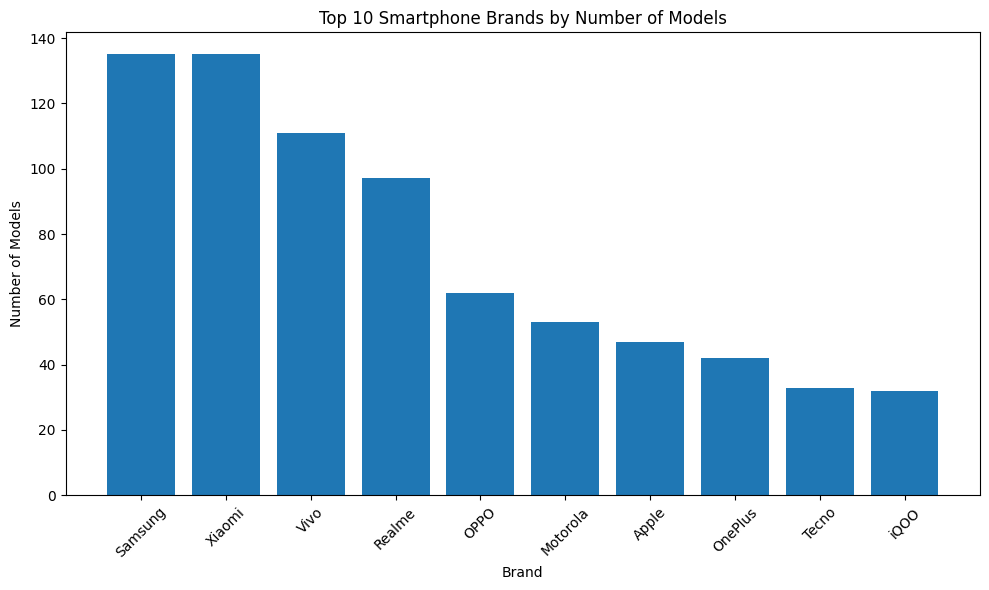

In [32]:
# TOP 10 BRANDS BY NUMBER OF MODELS
top_brands = df["brand"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_brands.index, top_brands.values)
plt.title("Top 10 Smartphone Brands by Number of Models")
plt.xlabel("Brand")
plt.ylabel("Number of Models")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


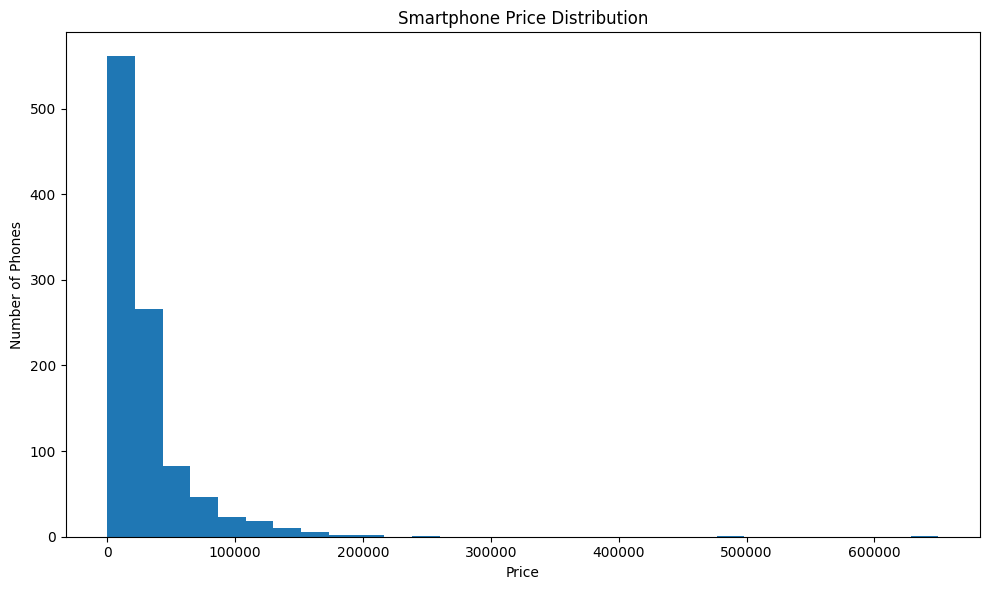

In [33]:
# PRICE DISTRIBUTION
plt.figure(figsize=(10, 6))
plt.hist(df["price"].dropna(), bins=30)
plt.title("Smartphone Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Phones")
plt.tight_layout()
plt.show()



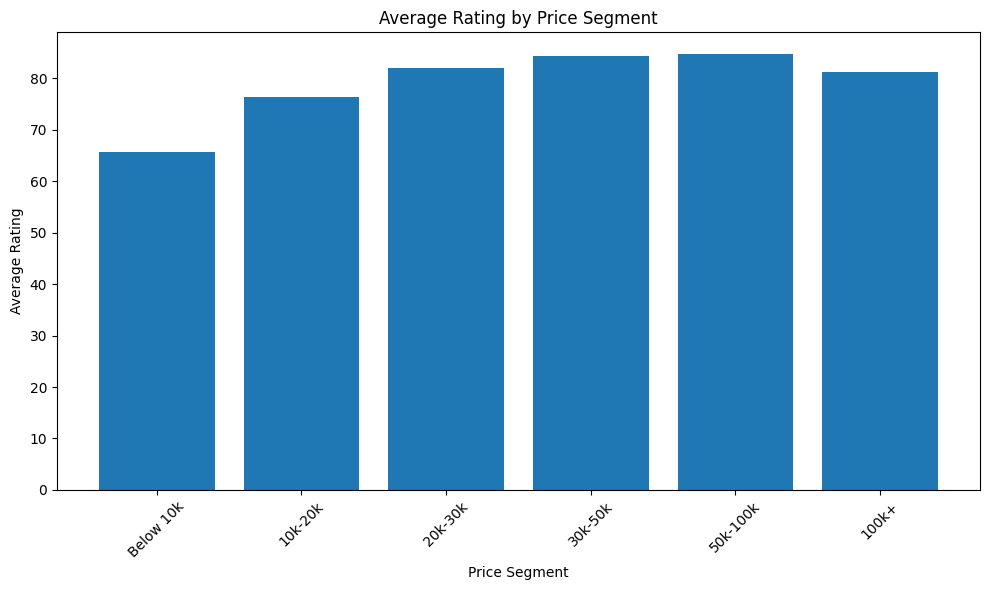

In [34]:
# AVERAGE RATING BY PRICE SEGMENT

avg_rating_segment = df.groupby("price_segment", observed=False)["rating"].mean()

plt.figure(figsize=(10, 6))
plt.bar(avg_rating_segment.index.astype(str), avg_rating_segment.values)
plt.title("Average Rating by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


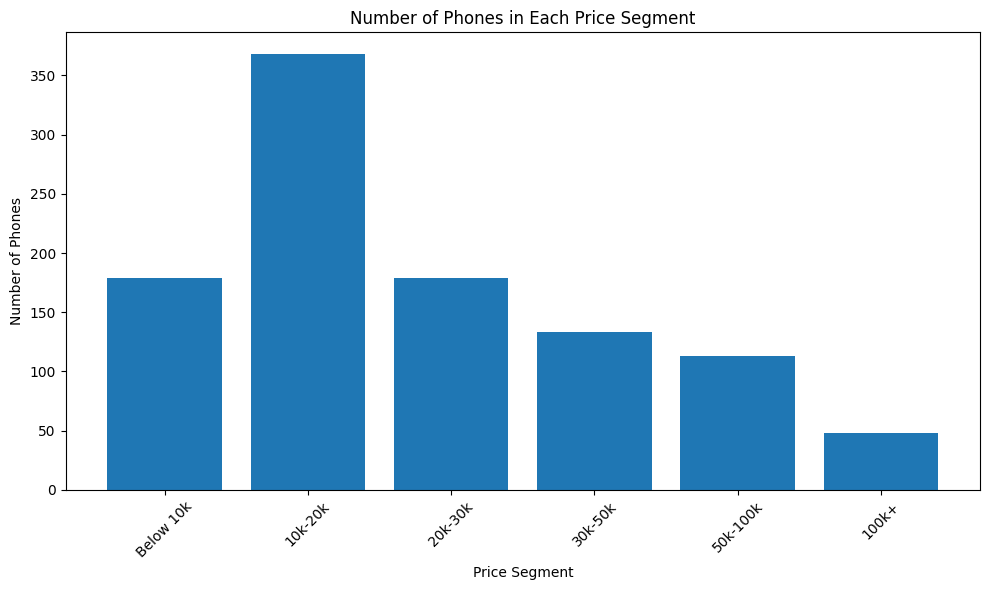

In [35]:
# NUMBER OF PHONES IN EACH PRICE SEGMENT
price_segment_count = df["price_segment"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(price_segment_count.index.astype(str), price_segment_count.values)
plt.title("Number of Phones in Each Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Number of Phones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



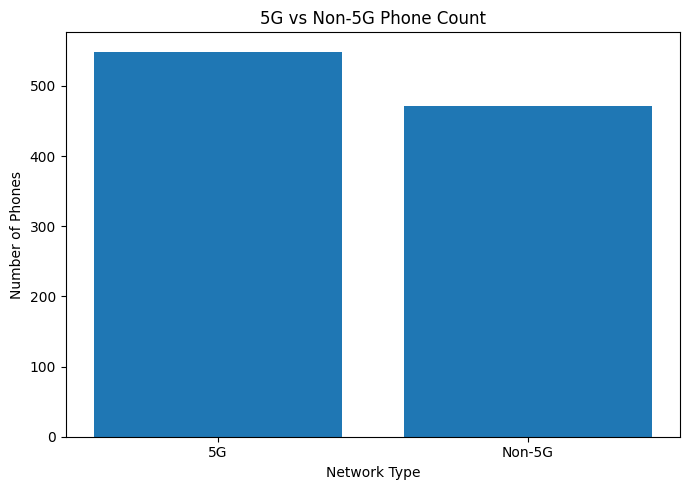

In [36]:
# 5G VS NON-5G PHONE COUNT
network_count = df["is_5g"].value_counts()
network_labels = ["5G" if x == True else "Non-5G" for x in network_count.index]

plt.figure(figsize=(7, 5))
plt.bar(network_labels, network_count.values)
plt.title("5G vs Non-5G Phone Count")
plt.xlabel("Network Type")
plt.ylabel("Number of Phones")
plt.tight_layout()
plt.show()

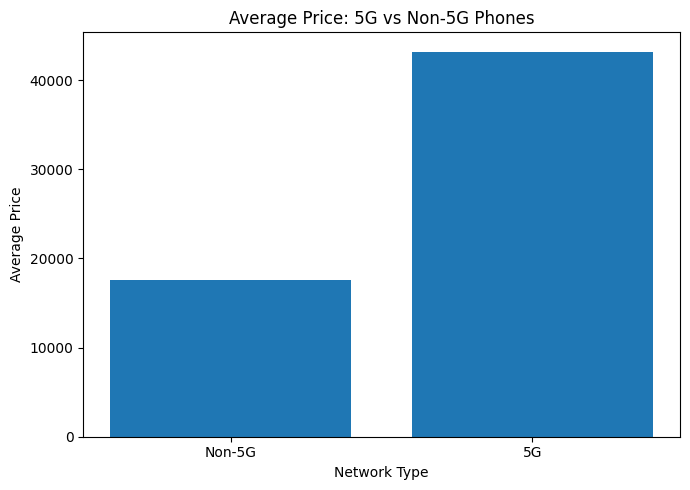

In [37]:
#  AVERAGE PRICE: 5G VS NON-5G
avg_price_network = df.groupby("is_5g")["price"].mean()
network_labels = ["Non-5G", "5G"]

plt.figure(figsize=(7, 5))
plt.bar(network_labels, avg_price_network.values)
plt.title("Average Price: 5G vs Non-5G Phones")
plt.xlabel("Network Type")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()


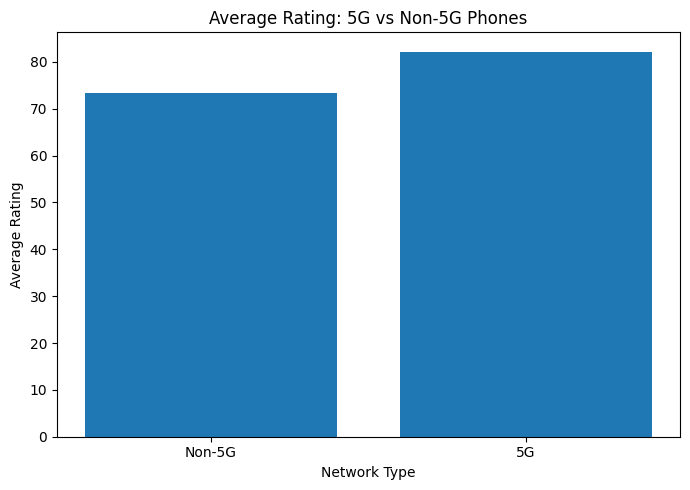

In [38]:
# AVERAGE RATING: 5G VS NON-5G
avg_rating_network = df.groupby("is_5g")["rating"].mean()

plt.figure(figsize=(7, 5))
plt.bar(network_labels, avg_rating_network.values)
plt.title("Average Rating: 5G vs Non-5G Phones")
plt.xlabel("Network Type")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

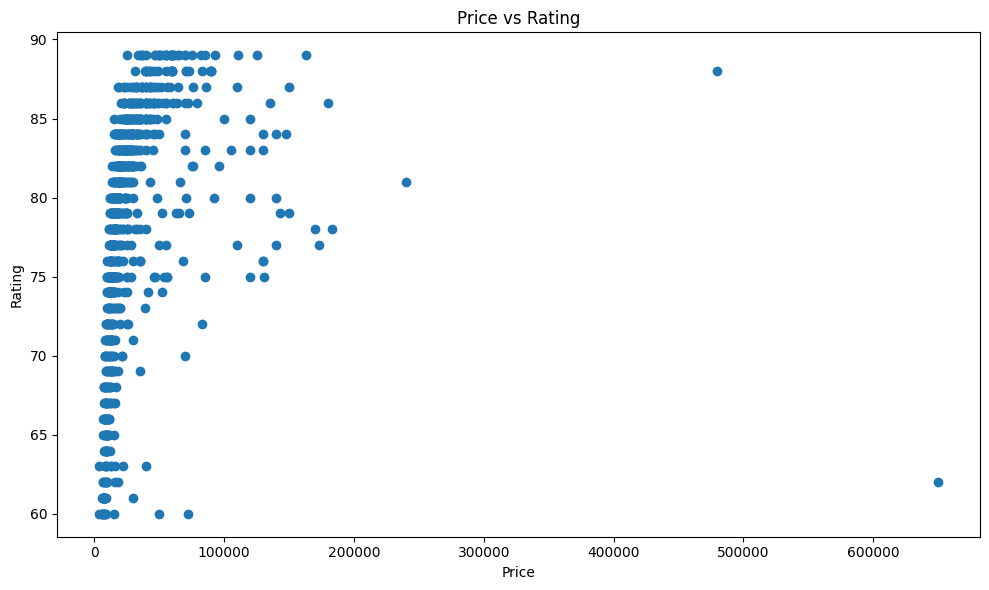

In [39]:
# PRICE VS RATING SCATTER PLOT
plt.figure(figsize=(10, 6))
plt.scatter(df["price"], df["rating"])
plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()


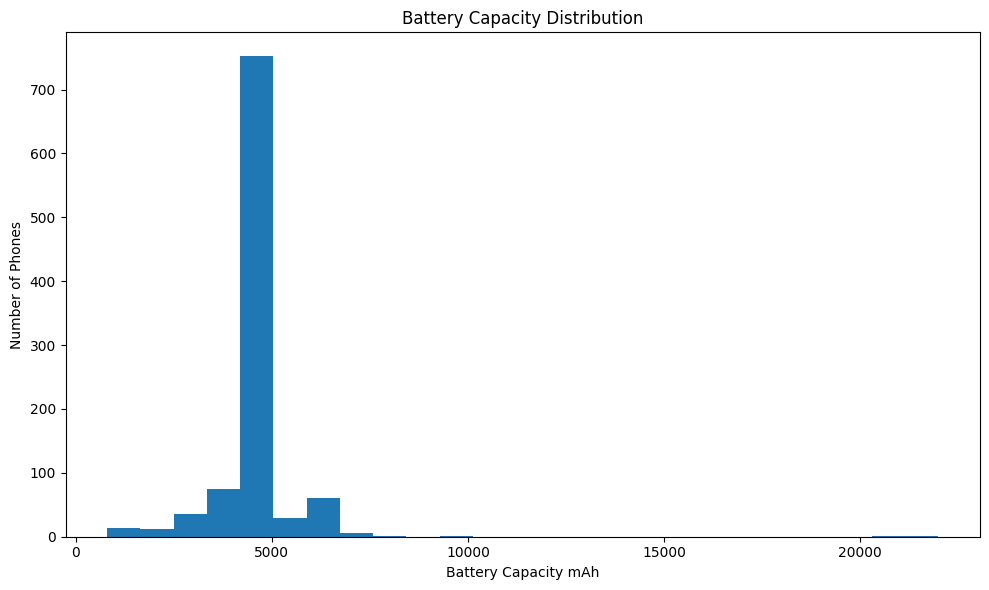

In [41]:
# CAPACITY DISTRIBUTION
plt.figure(figsize=(10, 6))
plt.hist(df["battery_mah"].dropna(), bins=25)
plt.title("Battery Capacity Distribution")
plt.xlabel("Battery Capacity mAh")
plt.ylabel("Number of Phones")
plt.tight_layout()
plt.show()


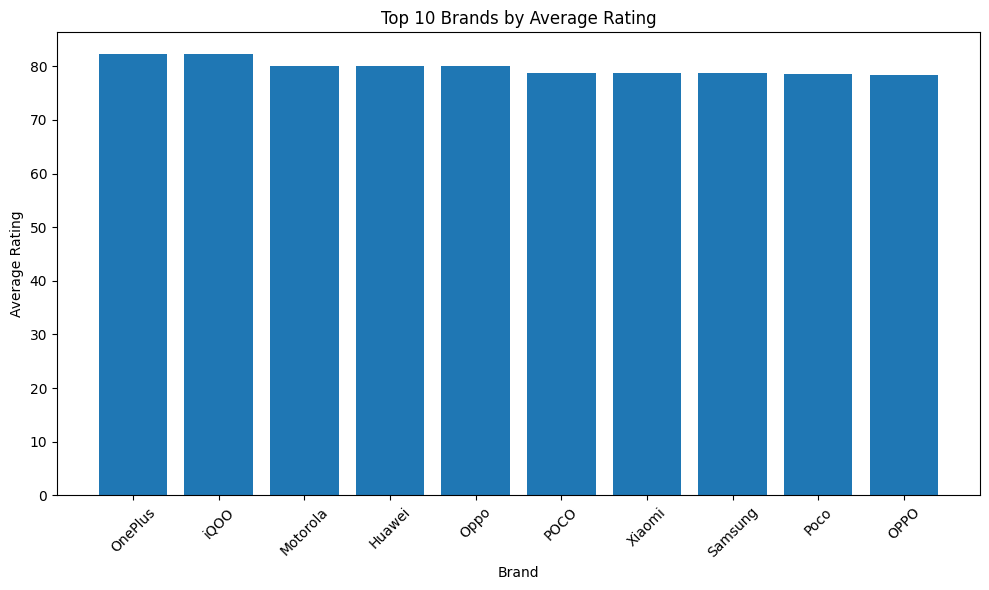

In [42]:
#  TOP 10 BRANDS BY AVERAGE RATING
brand_rating = df.groupby("brand").agg(
    models=("model", "count"),
    average_rating=("rating", "mean")
)

brand_rating = brand_rating[brand_rating["models"] >= 10]
brand_rating = brand_rating.sort_values("average_rating", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(brand_rating.index, brand_rating["average_rating"])
plt.title("Top 10 Brands by Average Rating")
plt.xlabel("Brand")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


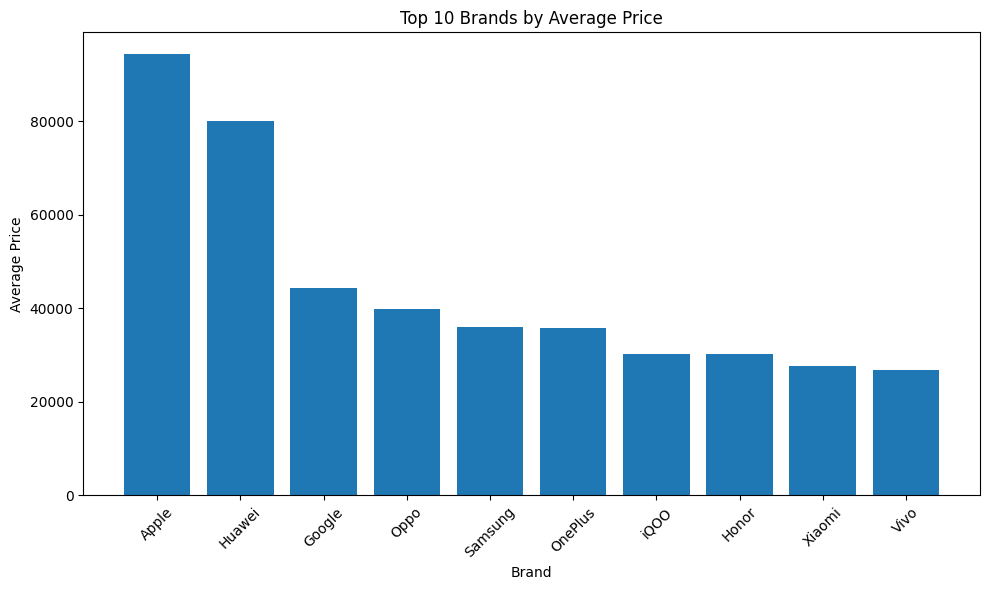

In [44]:
#  TOP 10 BRANDS BY AVERAGE PRICE
brand_price = df.groupby("brand").agg(
    models=("model", "count"),
    average_price=("price", "mean")
)

brand_price = brand_price[brand_price["models"] >= 10]
brand_price = brand_price.sort_values("average_price", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(brand_price.index, brand_price["average_price"])
plt.title("Top 10 Brands by Average Price")
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


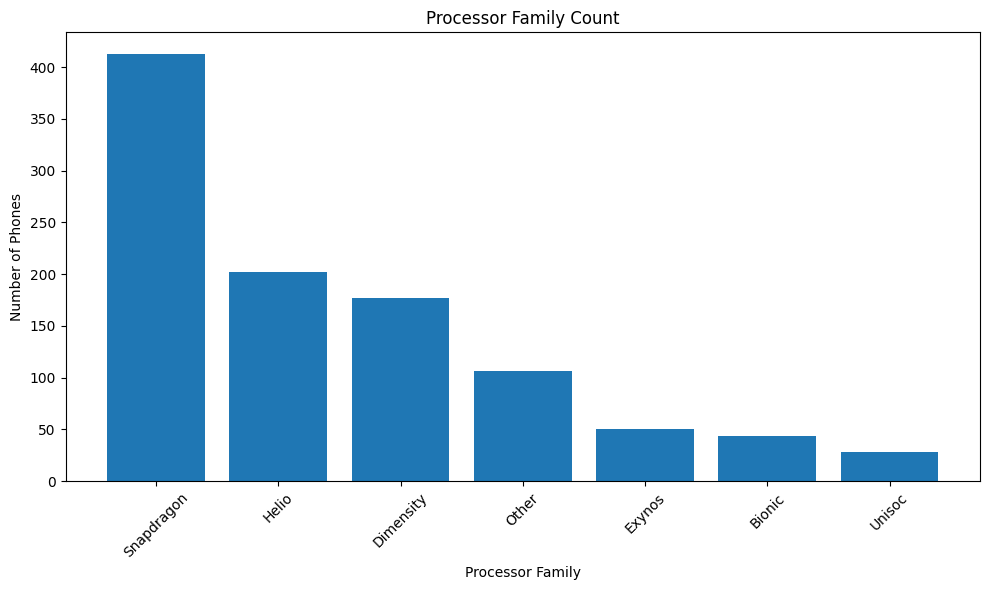

In [45]:
# 16. PROCESSOR FAMILY COUNT
processor_count = df["processor_family"].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(processor_count.index, processor_count.values)
plt.title("Processor Family Count")
plt.xlabel("Processor Family")
plt.ylabel("Number of Phones")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

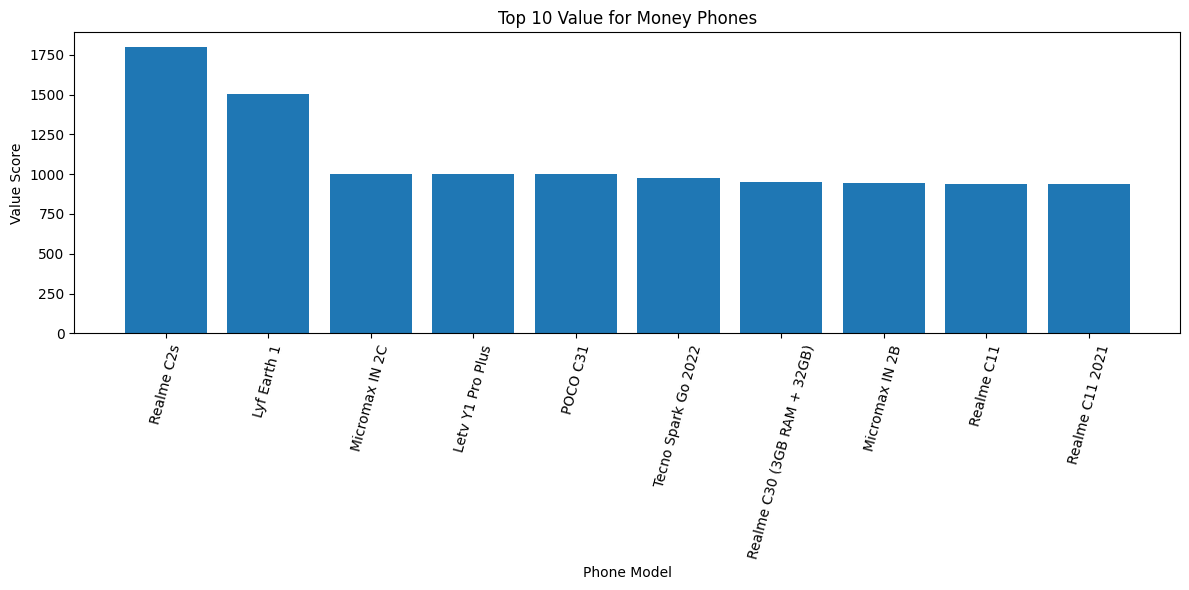

In [47]:
#  VALUE FOR MONEY TOP 10 PHONES
top_value = df.dropna(subset=["value_score"]).sort_values(
    "value_score",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_value["model"], top_value["value_score"])
plt.title("Top 10 Value for Money Phones")
plt.xlabel("Phone Model")
plt.ylabel("Value Score")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

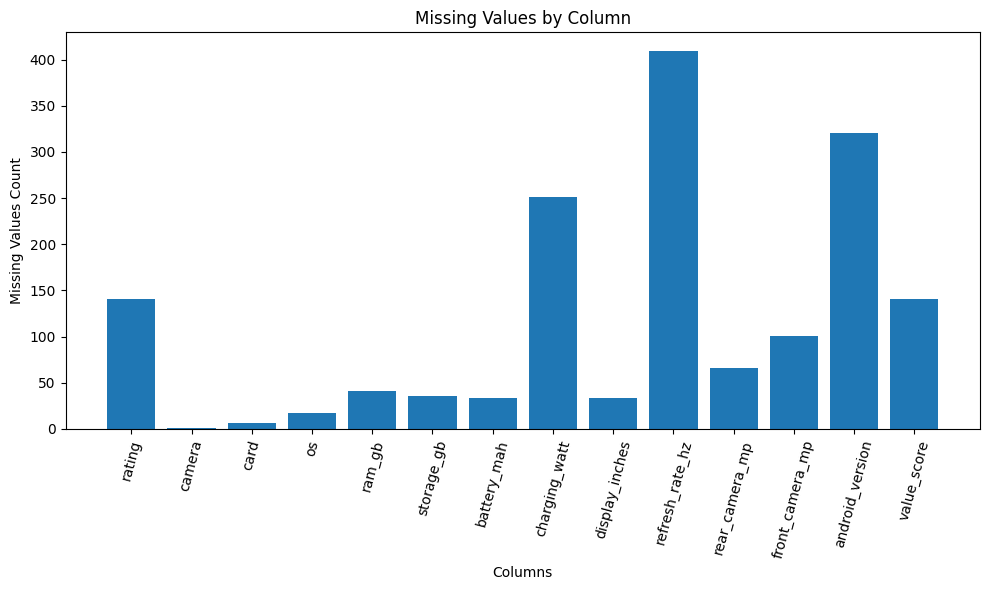

In [48]:
# MISSING VALUES VISUALIZATION
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 6))
plt.bar(missing_values.index, missing_values.values)
plt.title("Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()